In [2]:
import scanpy as sc
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
adata = sc.read_h5ad('/msc/home/q56ppene/cellwhisperer/cellwhisperer/tmp/cellxgene.h5ad',
                     backed='r')

new_cluster_annot = pd.read_csv("/msc/home/mschae83/cellwhisperer_private/results/archs4_geo/cellwhisperer_clip_v1/llava_curated_annotated_clusters.csv", index_col=0)

if True:
    adata.obs["cluster_label_old"] = adata.obs["cluster_label"].copy()
    # the index of new_cluster_annot should be matched with leiden 
    adata.obs["cluster_label"] = new_cluster_annot.loc[adata.obs["leiden"].astype(int).values, "curated_labels"].values

metadata_json= "/msc/home/mschae83/cellwhisperer/results/archs4_geo/annotations.json"
metadata_df = pd.read_json(metadata_json, orient='index')

[('source_name:', 10335), ('and', 10265), ('of', 10202), ('', 9876), ('to', 9849), ('in', 9797), ('the', 9512), ('with', 9460), ('from', 8862), ('None', 8712), ('a', 8443), ('were', 8226), ('cell', 7920), ('cells', 7614), ('We', 7427), ('by', 7176), ('as', 6922), ('for', 6481), ('cell_type:', 6027), ('at', 5960), ('was', 5444), ('we', 5314), ('that', 5307), ('expression', 5217), ('samples', 5161), ('In', 4805), ('on', 4708), ('blood', 4441), ('tissue:', 4344), ('analysis', 4288), ('these', 4251), ('transcriptional', 4130), ('The', 4099), ('is', 4096), ('RNA', 4077), ('sex:', 3994), ('are', 3918), ('or', 3765), ('peripheral', 3667), ('age:', 3619), ('using', 3595), ('identify', 3551), ('associated', 3522), ('may', 3501), ('human', 3493), ('an', 3461), ('two', 3438), ('each', 3429), ('well', 3372), ('3', 3218), ('clinical', 3214), ('protein', 3195), ('single', 3144), ('5', 3120), ('sequencing', 3022), ('single-cell', 2930), ('into', 2916), ('gene', 2842), ('which', 2803), ('have', 2780),

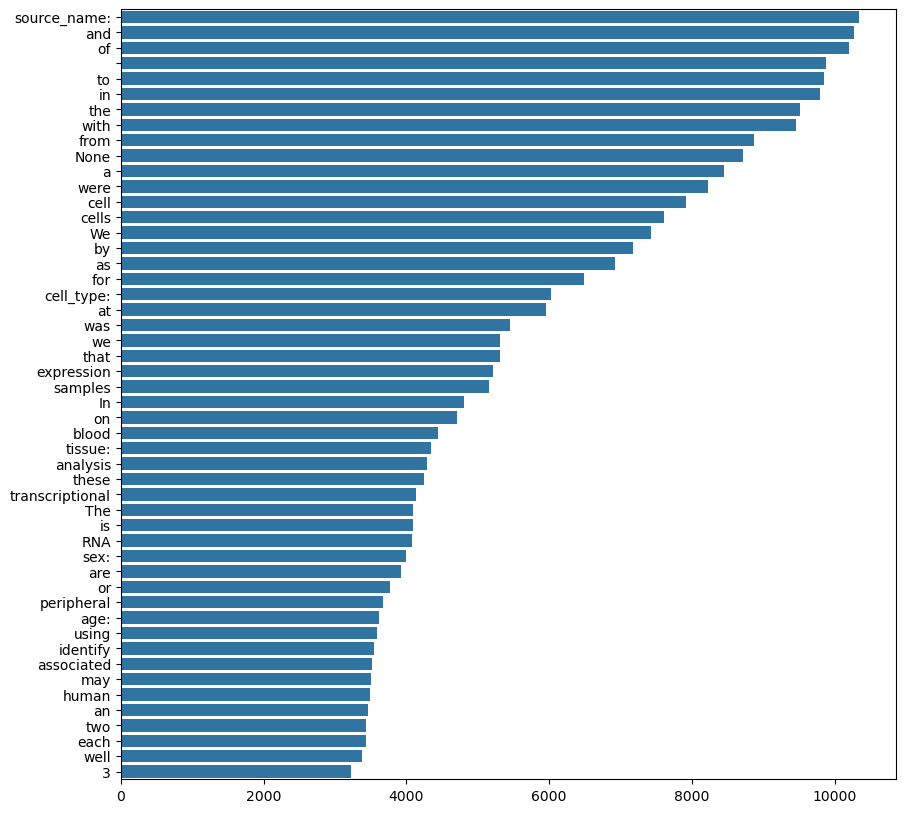

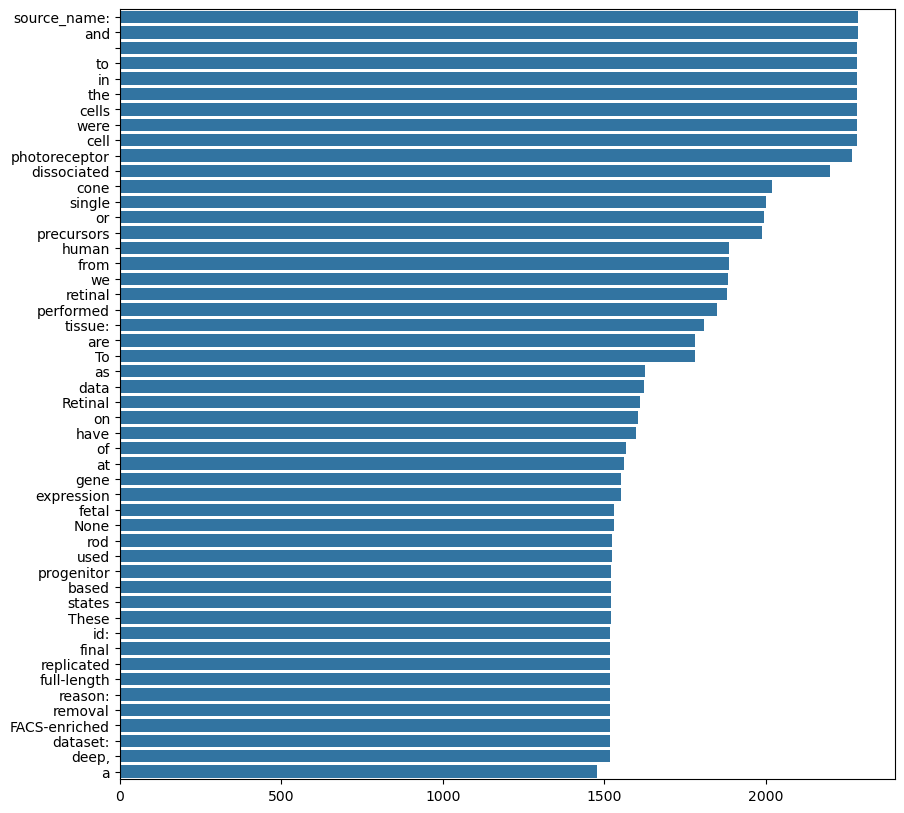

In [11]:
for cluster in ["Heightened immune activity with neutrophil involvement","Fetal retinal cells undergoing photoreceptor differentiation"]:

    cell_ids_this_cluster = adata.obs.index[adata.obs["cluster_label"]==cluster]
    metadata_df_this_cluster = metadata_df.loc[cell_ids_this_cluster]

    metadata_words = []
    for cell_id in cell_ids_this_cluster:
        metadata = " ".join([str(x) for x in metadata_df.loc[cell_id].values])
        metadata_words += list(set(metadata.split(" ")))

    word_counts = Counter(metadata_words)

    top_50_words = word_counts.most_common(50)

    # plot
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.barplot(x=[x[1] for x in top_50_words], y=[x[0] for x in top_50_words], ax=ax)
    
    # print top 100 words
    print(word_counts.most_common(100))
    

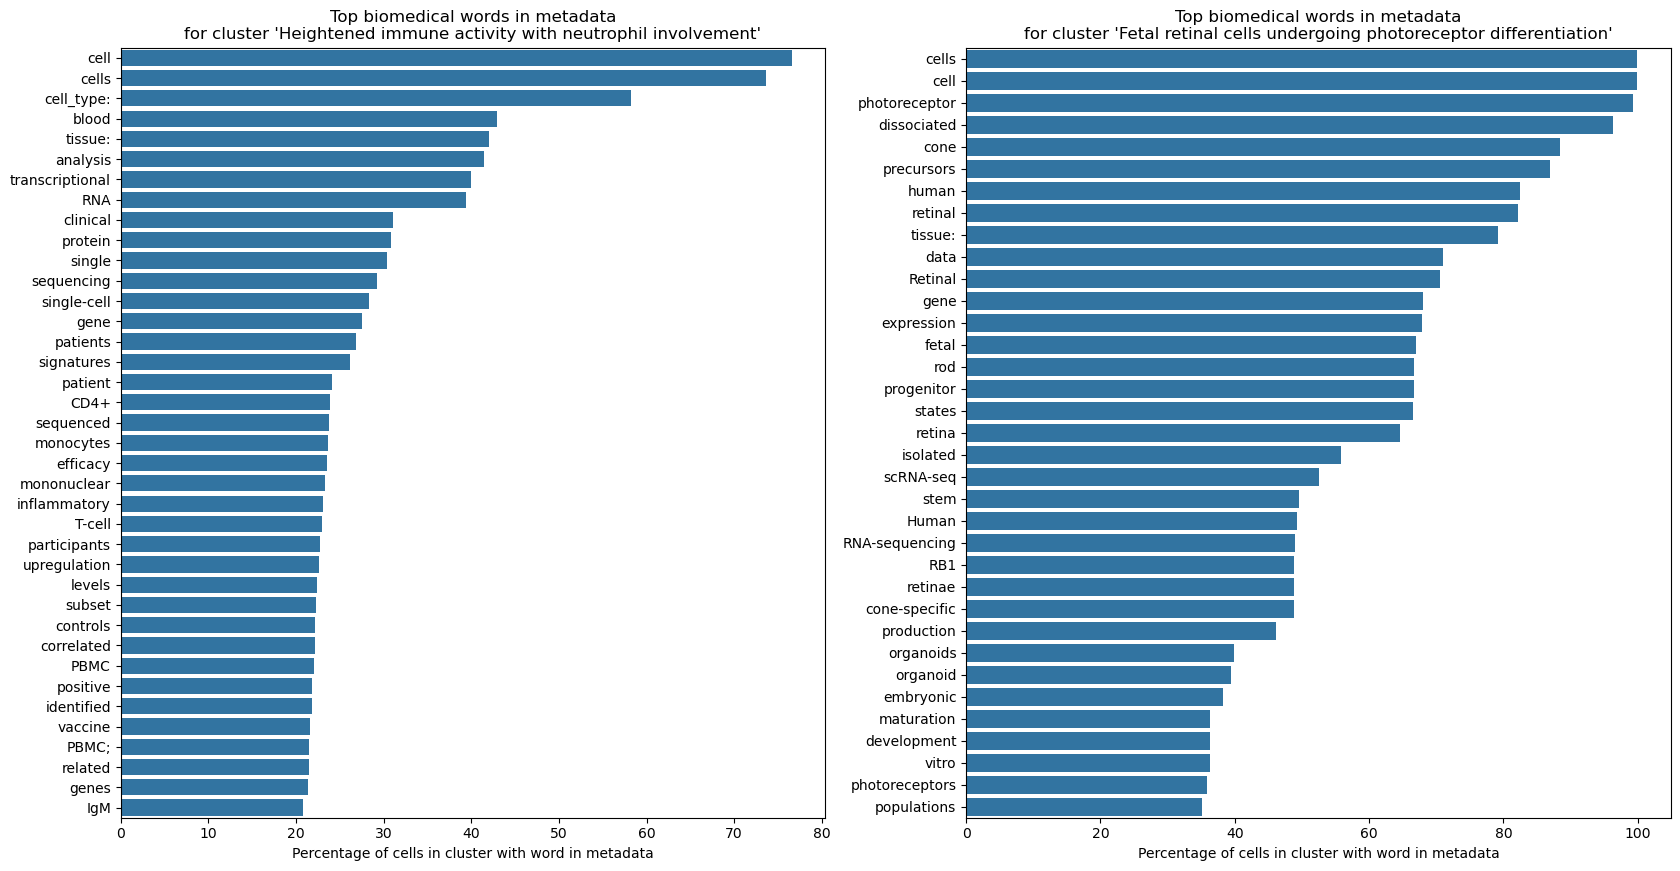

In [10]:
# Gemini 2.5 Pro prompt in the web app:  'Extract only words with biomedical relavance and return the list in the same format: ' and then the list of top 100 words from above. Results pasted below:

top_biomedical_words_dict = {"Heightened immune activity with neutrophil involvement":
                             [('cell', 7920), ('cells', 7614), ('cell_type:', 6027), ('blood', 4441), ('tissue:', 4344), ('analysis', 4288), ('transcriptional', 4130), ('RNA', 4077), ('clinical', 3214), ('protein', 3195), ('single', 3144), ('sequencing', 3022), ('single-cell', 2930), ('gene', 2842), ('patients', 2772), ('signatures', 2712), ('patient', 2497), ('CD4+', 2472), ('sequenced', 2454), ('monocytes', 2450), ('efficacy', 2429), ('mononuclear', 2410), ('inflammatory', 2386), ('T-cell', 2379), ('participants', 2349), ('upregulation', 2339), ('levels', 2314), ('subset', 2306), ('controls', 2298), ('correlated', 2294), ('PBMC', 2284), ('positive', 2263), ('identified', 2255), ('vaccine', 2231), ('PBMC;', 2227), ('related', 2224), ('genes', 2212), ('IgM', 2150)],
                             "Fetal retinal cells undergoing photoreceptor differentiation":
                             [('cells', 2283), ('cell', 2282), ('photoreceptor', 2268), ('dissociated', 2200), ('cone', 2020), ('precursors', 1987), ('human', 1886), ('retinal', 1879), ('tissue:', 1810), ('data', 1623), ('Retinal', 1611), ('gene', 1553), ('expression', 1552), ('fetal', 1531), ('rod', 1524), ('progenitor', 1522), ('states', 1521), ('retina', 1476), ('isolated', 1275), ('scRNA-seq', 1201), ('stem', 1132), ('Human', 1126), ('RNA-sequencing', 1118), ('RB1', 1116), ('retinae', 1116), ('cone-specific', 1116), ('production', 1054), ('organoids', 911), ('organoid', 902), ('embryonic', 874), ('maturation', 831), ('development', 830), ('vitro', 830), ('photoreceptors', 821), ('populations', 804)]}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for i, (cluster_name, biomedical_top_words) in enumerate(top_biomedical_words_dict.items()):

    cluster_size = adata.obs[adata.obs["cluster_label"]==cluster_name].shape[0]
    sns.barplot(x=[100*(x[1]/cluster_size) for x in biomedical_top_words], y=[x[0] for x in biomedical_top_words], ax=axes[i])
    plt.sca(axes[i])
    plt.xlabel("Percentage of cells in cluster with word in metadata")
    plt.title(f"Top biomedical words in metadata\nfor cluster '{cluster_name}'")
plt.show()

# Older analyses (not included in the response letter) follow below:

In [4]:
# Get a list of all words in cluster names:
words = []
for cluster in adata.obs.cluster_label.unique():
    words.extend(cluster.split())
# Count the frequency of each word:
word_counts = Counter(words)
print(word_counts)

for cluster in adata.obs.cluster_label_old.unique():
    words.extend(cluster.split())

print(set(x.lower() for x in words))

Counter({'cells': 69, 'with': 58, 'immune': 39, 'in': 38, 'and': 27, 'cell': 26, 'response': 22, 'Active': 16, 'cancer': 16, 'active': 15, 'differentiation': 15, 'epithelial': 11, 'diverse': 11, 'Cells': 9, 'T': 9, 'interaction': 8, 'remodeling': 8, 'breast': 8, 'sample': 8, 'to': 7, 'complex': 7, 'cultured': 7, 'Heterogeneous': 7, 'from': 7, 'differentiating': 6, 'line': 6, 'Heightened': 6, 'Proliferating': 6, 'neural': 6, 'types': 6, 'Healthy': 6, 'microenvironment': 6, 'high': 5, 'phenotype': 5, 'HSPCs': 5, 'inflammation': 5, 'activity': 5, 'tumor': 5, 'supplemented': 5, 'mimicking': 5, 'Activated': 5, 'iPSC-derived': 5, 'cardiomyocytes': 4, 'Pancreatic': 4, 'potential': 4, 'DMEM': 4, 'involvement': 4, 'luminal': 4, 'human': 4, 'Diverse': 4, 'expressing': 4, 'Pluripotent': 4, 'adenocarcinoma': 4, 'proliferating': 3, 'HeLa': 3, 'gene': 3, 'expression': 3, 'iPSCs': 3, 'matrix': 3, 'heterogeneity': 3, 'HEK293T': 3, 'NPCs': 3, 'B': 3, 'hESCs': 3, 'towards': 3, 'islet': 3, 'metabolism': 

In [3]:
adata_nat_langauge_annot = sc.read_h5ad('/msc/home/mschae83/cellwhisperer_private/results/archs4_geo/full_data.h5ad',
                     backed='r')
adata.obs["natural_language_annotation"] = adata_nat_langauge_annot.obs.loc[adata.obs.index, "natural_language_annotation"]
adata.obs["mapped_ontology_terms"] = adata_nat_langauge_annot.obs.loc[adata.obs.index, "mapped_ontology_terms"]

[('and', 82829), ('of', 74040), ('the', 55739), ('in', 46683), ('to', 37396), ('with', 35409), ('were', 30495), ('cells', 27835), ('a', 25185), ('cell', 23849), ('for', 22227), ('from', 20242), ('', 19019), ('as', 13772), ('by', 13487), ('we', 11609), ('that', 11108), ('3', 11038), ('blood', 10950), ('at', 10492), ('We', 10432), ('source_name:', 10335), ('samples', 9856), ('was', 9724), ('T', 9620), ('month', 9454), ('single-cell', 8864), ('human', 8693), ('is', 8126), ('None', 8028), ('In', 7822), ('expression', 7487), ('The', 7478), ('on', 7272), ('correlated', 7112), ('using', 7011), ('or', 6977), ('RNA', 6740), ('levels', 6371), ('analysis', 6059), ('single', 6045), ('cell_type:', 6027), ('responses.', 5913), ('associated', 5890), ('clinical', 5882), ('malaria', 5614), ('RTS,S/AS01-associated', 5610), ('are', 5484), ('transcriptional', 5468), ('patients', 5447), ('these', 5261), ('peripheral', 4886), ('which', 4816), ('have', 4727), ('an', 4714), ('sequencing', 4674), ('tumor', 452

[('and', 18641), ('retinal', 8817), ('cone', 7783), ('in', 6629), ('cells', 6602), ('cell', 6103), ('to', 6100), ('the', 5430), ('were', 5318), ('of', 4987), ('human', 4981), ('photoreceptor', 4645), ('from', 4563), ('fetal', 4492), ('precursors', 3646), ('two', 3606), ('retina', 3315), ('', 3284), ('or', 3257), ('a', 3144), ('gene', 3073), ('expression', 3073), ('progenitor', 3046), ('FACS-enriched', 3038), ('single', 2889), ('as', 2791), ('organoids', 2627), ('organoid', 2539), ('at', 2472), ('with', 2380), ('rod', 2325), ('source_name:', 2285), ('dissociated', 2201), ('features', 2183), ('precursor', 2154), ('that', 2136), ('We', 2113), ('every', 2009), ('performed', 1920), ('by', 1915), ('we', 1896), ('et', 1813), ('tissue:', 1810), ('are', 1780), ('To', 1780), ('al.', 1743), ('Retinal', 1681), ('isolated', 1680), ('either', 1655), ('development', 1631), ('data', 1627), ('on', 1622), ('identify', 1607), ('organoid;', 1607), ('weeks', 1604), ('225', 1603), ('prep', 1602), ('publishe

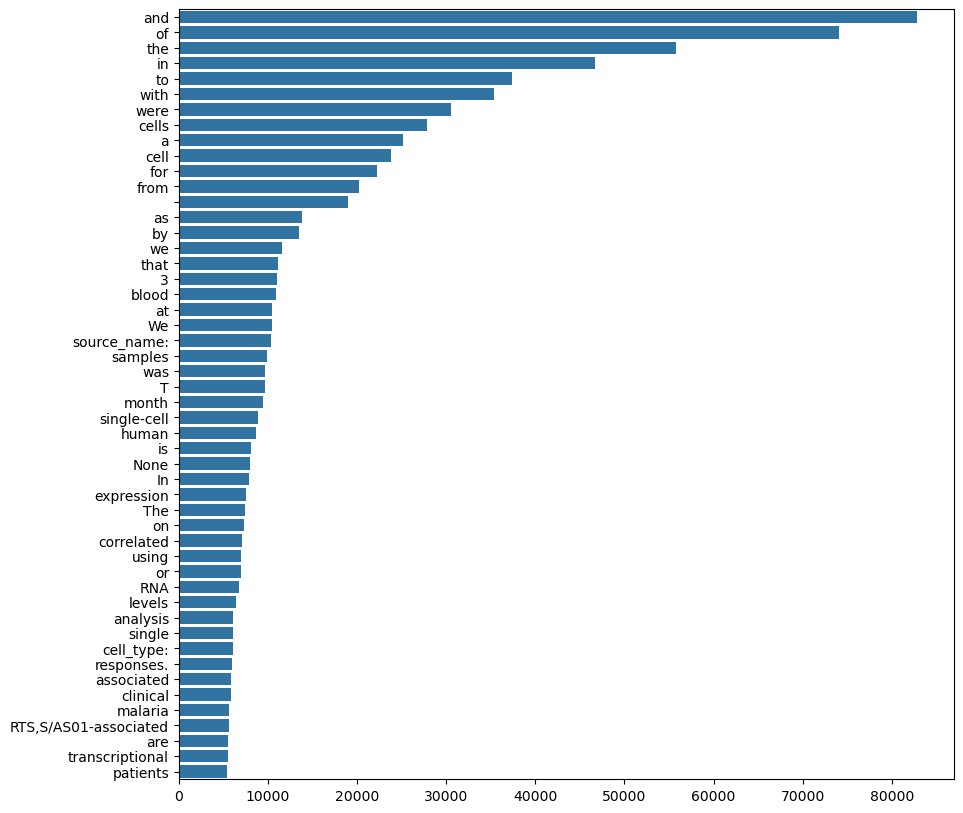

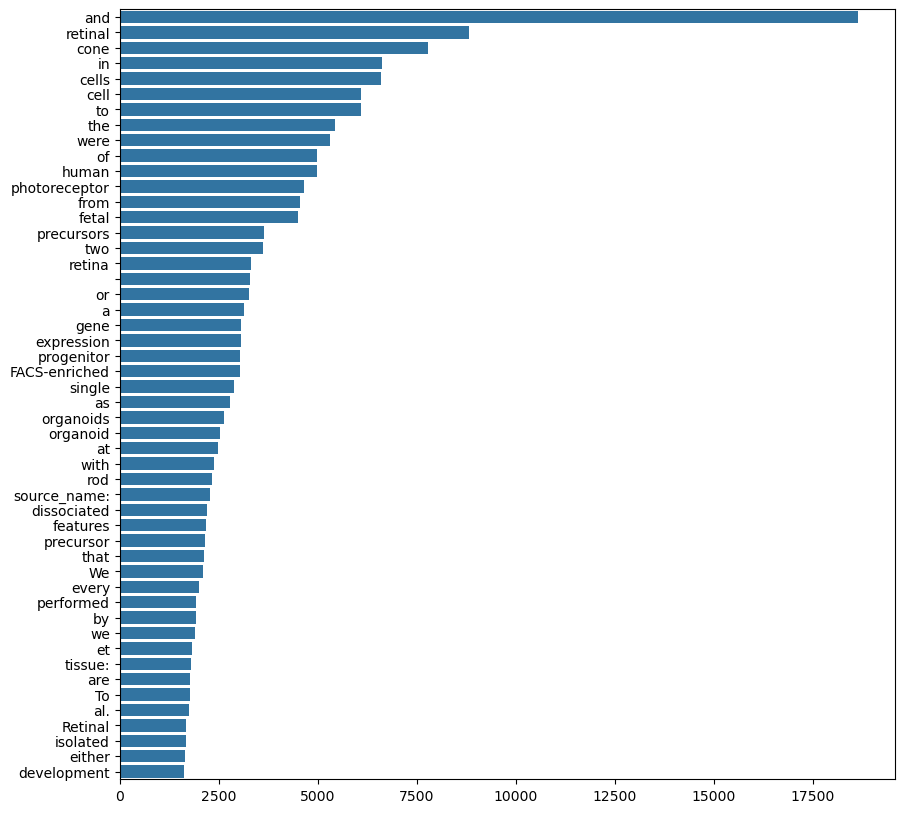

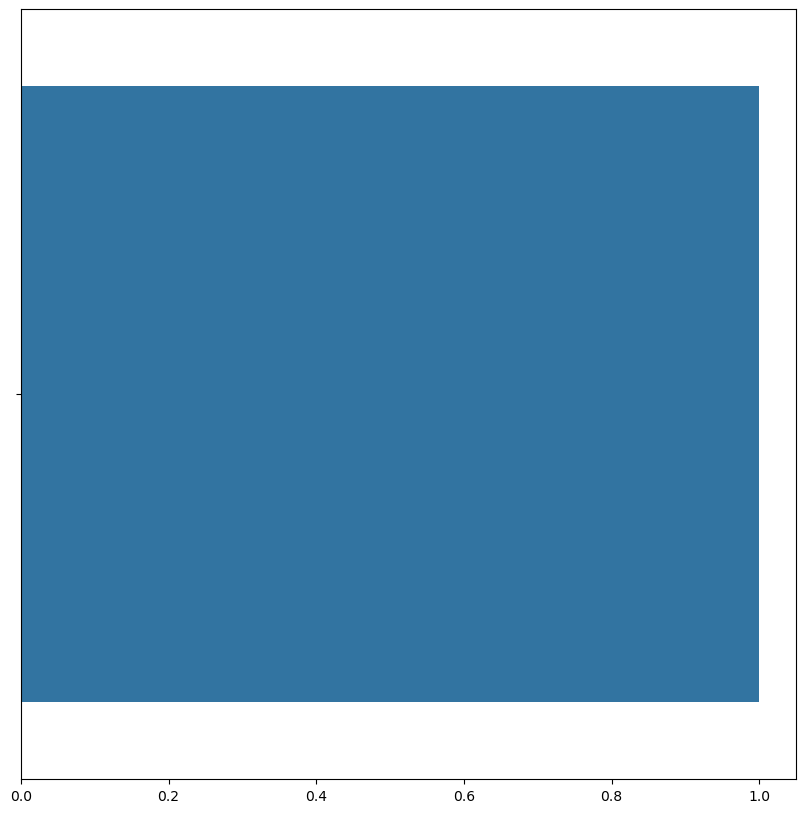

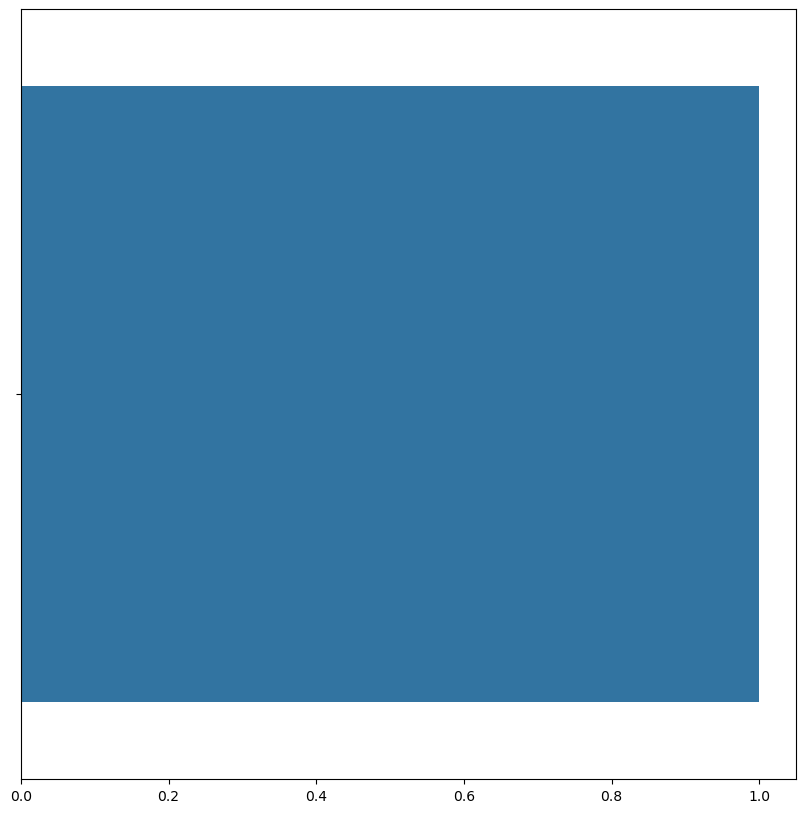

In [9]:
for cluster in ["Heightened immune activity with neutrophil involvement","Fetal retinal cells undergoing photoreceptor differentiation","SLE Patient's Active Immune Response","Retinal Progenitor and Photoreceptor Precursor Analysis"]:

    cell_ids_this_cluster = adata.obs.index[adata.obs["cluster_label"]==cluster]
    metadata_df_this_cluster = metadata_df.loc[cell_ids_this_cluster]

    metadata = ""
    for cell_id in cell_ids_this_cluster:
        metadata += " ".join([str(x) for x in metadata_df.loc[cell_id].values])

    word_counts = Counter(metadata.split(" "))

    top_50_words = word_counts.most_common(50)

    # plot
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.barplot(x=[x[1] for x in top_50_words], y=[x[0] for x in top_50_words], ax=ax)
    
    # print top 100 words
    print(word_counts.most_common(100))
    

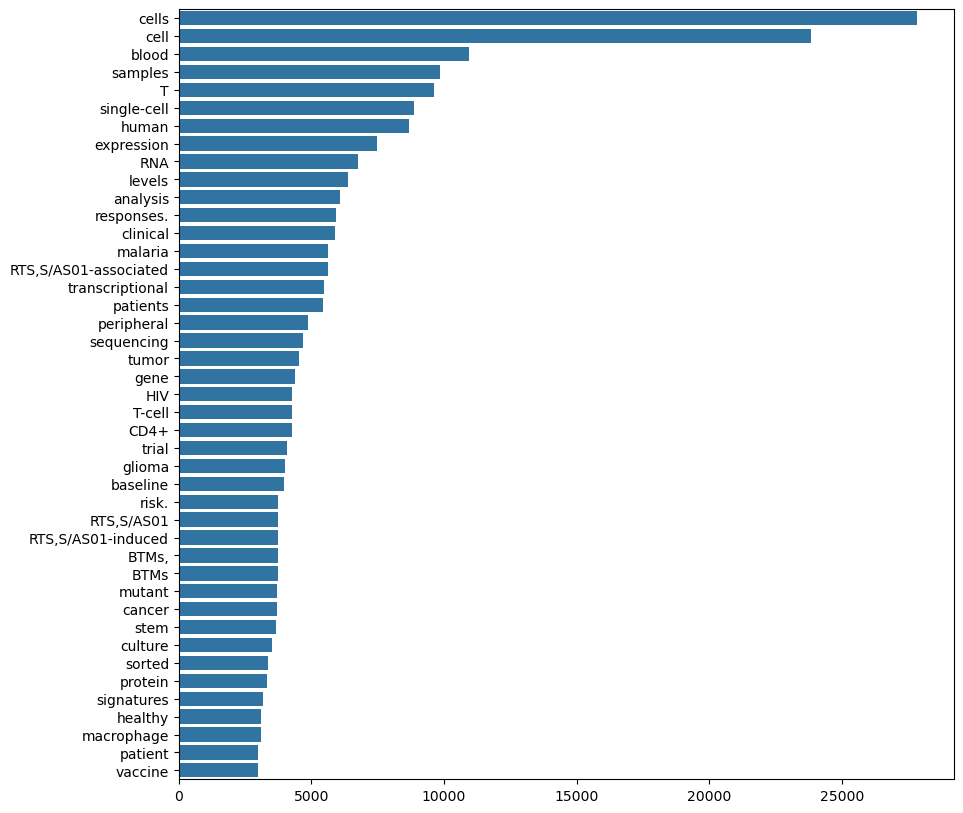

In [10]:
gemini_top_words=[('cells', 27835), ('cell', 23849), ('blood', 10950), ('samples', 9856), ('T', 9620), ('single-cell', 8864), ('human', 8693), ('expression', 7487), ('RNA', 6740), ('levels', 6371), ('analysis', 6059), ('responses.', 5913), ('clinical', 5882), ('malaria', 5614), ('RTS,S/AS01-associated', 5610), ('transcriptional', 5468), ('patients', 5447), ('peripheral', 4886), ('sequencing', 4674), ('tumor', 4529), ('gene', 4390), ('HIV', 4280), ('T-cell', 4274), ('CD4+', 4270), ('trial', 4061), ('glioma', 3985), ('baseline', 3972), ('risk.', 3741), ('RTS,S/AS01', 3740), ('RTS,S/AS01-induced', 3740), ('BTMs,', 3740), ('BTMs', 3740), ('mutant', 3702), ('cancer', 3693), ('stem', 3662), ('culture', 3512), ('sorted', 3359), ('protein', 3310), ('signatures', 3159), ('healthy', 3114), ('macrophage', 3099), ('patient', 2992), ('vaccine', 2985)]
# plot as bar plots
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(x=[x[1] for x in gemini_top_words], y=[x[0] for x in gemini_top_words], ax=ax)
plt.show()

In [5]:
len(set(x.lower() for x in words))

488

In [11]:
# By Gemini 2.5 pro
word_categories={
  "biomedical_terms": [
    "response", "drug-treated", "cultured", "pdzd2", "mycobacterium", 
    "hesc-derived", "cd4+", "becs", "adaptive", "marrow", "eto-induced", 
    "mds", "yoruba", "genes", "undifferentiated", "ulcer", "cerebellum", 
    "itregs", "myeloid", "786-o", "cultures", "gene", "retinal", "mcf-7", 
    "dmso-treated", "npcs", "psoriasis", "atopic", "erythropoiesis", 
    "pfoa-treated", "osteosarcoma", "ovarian", "naive", "hek293t", "evts", 
    "keratinocytes", "photoreceptor", "modcs", "embryo", "oscc", 
    "meningitidis", "er+", "hormone", "differentiation", "fibroblasts", 
    "placental", "nuclei,", "neural", "cd8", "subtype", "pdx", "dmso", 
    "post-pi3kδ", "pluripotency", "pbmcs", "endothelial", "beta", 
    "hepatocyte", "proliferation", "derived", "non-saa", "metastasis", 
    "cardiac", "veev", "patient's", "activated", "adipose", "jurkat", 
    "mda-mb-231", "bach2", "lipid", "normoxic", "tbx5", "dna", 
    "smarca4-knockout", "poised", "1640", "mammary", "rrmm", "matrix", 
    "treatment", "carcinoma", "influenza:", "plasma", "williams-beuren", 
    "k562", "melanocytes", "ezh2-overexpressing", "medium", "pancreatic", 
    "patient", "pa-treated", "post-rfa", "t2d", "cells:", "sera", 
    "exhausting", "cd34+", "fp55", "female", "pluripotent", "hfo", 
    "monocyte-derived", "asthmatic", "cells", "wound", "organoids", "a549", 
    "neurodevelopmental", "ccrcc", "pbmc", "phenotype", "naptha", 
    "expression", "emt", "human", "pfas", "rpmi", "hepatocytes", 
    "progenitors", "cytotoxic", "fulvestrant", "mtb", "hct116", 
    "post-palbociclib", "cells'", "tumor", "fgfr2_k660n,", "tissue", "mcf7", 
    '"inflamed', "myocytes", "phototransduction", "mucus", "ecm", 
    "angiogenesis", "therapy", "imr90", "nhbe", "lineage", "breast", 
    "fallopian", "transformation", "cardiomyocytes", "proliferating", 
    "melanoma", "stress", "muscle", "cd38+", "macrophages'", "fgf2", 
    "post-vhgo", "myelofibrosis", "hela", "expressing", "stressed", 
    "naptha-treated", "etoposide", "baff-treated", "lavage", "mnd", 
    "metabolic", "culture", "responding", "cd3+cd4+", "differentiating", 
    "cellular", "irradiated", "nondiabetic", "cell-mediated", "143b", 
    "nuclei", "epithelium", "intestine", "ventricular", "adapted", 
    "hipsc-derived", "neurons", "huh7", "progenitor", "ready", "tc-83", 
    "hnscc", "msi", "sclc", "retina", "immortalized", "nasal", 
    "macrophages", "dmem", "glioblastoma", "neuroinflammation", 
    "mtb-infected", "lymphocytes", "skin", "neonatal", "liver-specific", 
    "inflammatory", "differentiated", "stimulated", "transcriptome", "high", 
    "heightened", "disease", "feeder-free", "drug", "dermal", "her2", 
    "early-stage", "serous", "vpa", "glucose", "fibrosis", "t", "leukemia", 
    "neisseria", "cd8+", "metabolism", "inflamed", "kidney", "stress-induced", 
    "immune", "lymphocyte", "22rv1", "normal", "active,", "tnbc", 
    "immune-related", "multi-lineage", "hfib-myod", "treated", "cells,", "evs", 
    "dengue-infected", "cd27+", "erythroleukemia", "hfo-treated", "cell", 
    "cancer", "trophoblast", "neuronal", "bronchial", "gyrus", "8-cell", 
    "293t", "stem-like", "fetal", "memory", "colorectal", "inhibition", "ms", 
    "inflammation", "epithelial", "hepg2", "microenvironment", "gland", 
    "hepatocyte-dominant", "activation", "glioma", "colitis", "untreated", 
    "post-dietary", "sars-cov-2", "als", "b-cell", "lcls", "undergoing", 
    "hdfs", "pdac", "myelofibrosis-impacted", "fibroblast", 
    "adenocarcinoma", "ileal", "reprogramming", "mscs", "islet", 
    "neuroendocrine", "igan-associated", "ali", "skeletal", "bone", "liver", 
    "tuberculosis", "sle", "antibody", "huntington's", "luad", "u87", 
    "prostate", "h1n1-induced", "escc", "hd", "hepatoma", "beas-2b", 
    "dengue", "luminal", "brain", "hematopoietic", "braf", "rna", "biopsy", 
    "platelets", "organoid", "stem", "lung", "intestinal", "metastatic", 
    "ipscs", "infected", "huvecs", "mesangial", "t47d", "blood", "kir+", 
    "spermatogenesis", "hspcs", "h9", "501mel", "hipscs", "renal", "abc", 
    "bp1", "cancerous", "hcv", "wi-38", "epidermal", "preimplantation", 
    "lymphoma", "hematopoiesis", "monocytes", "precursor", "myeloma", 
    "dermatitis", "hescs", "obese", "male", "neutrophil", "lin-cd34+", 
    "erythrocytes", "syndrome", "a375", "gestation", "interferon", "b", 
    "ipsc-derived", "t-all", "stem/progenitor", "high-grade", "ebs", 
    "yoruba-derived", "multipotent", "infection", "dlbcl", "extracellular", 
    "ulcerative", "signs", "supplements"
  ],
  "filler_words_prepositions_etc": [
    "er", "after", "with", "for", "into", "of", "at", "to", "no", 
    "towards", "under", "&", "and", "in", "by", "from"
  ],
  "other_words": [
    "maintaining", "30-day", "substance", "exposed", "presence", 
    "composition", "conditions", "key", "cluster", "large", "active", 
    "diversity", "middle", "triple", "10", "involved", "characteristics", 
    "interaction", "activity", "involvement\"", "actively", "day", "early", 
    "supplemented", "indoor", "models", "repair", "petroleum", "dynamic", 
    "damage", "various", "plasticity", "state\"", "adolescent", "positive", 
    "profile\"", "indicate", "reporter", "label", "developing", "mode", 
    "production", "8-week", "functions", "defense", "sorted", "signals", 
    "function", "transitional", "transitioning", "stage", "diluted", 
    "system", "pathways", "analyzed", "adaptations", "states", "role", 
    "exposure", "multiple", "potential", "broad", "heterogeneity", '"ready', 
    "show", "post-passage", "15", "mimicking", "post", "types", "line", 
    "spectrum", "1", "mixed", "upregulation", "3d", "intervention", 
    "mechanisms", "development", "commitment", "showing", "heterogeneous", 
    "mimic", "sample", "inhibitor-treated", "analysis", "single", "healing", 
    "state", "markers", "growth", "remodeling", "complexity", "detected", 
    "identities", "air", "traits", "combinations", "tube", "involvement", 
    "robust", "complex", "extract", "6-hour", "temporal", "30", "pm", "healthy" 
  ]
}

In [12]:
all_annot=list(word_categories["biomedical_terms"])+list(word_categories["filler_words_prepositions_etc"])+list(word_categories["other_words"])

all_words=set(x.lower() for x in words)
print([x for x in all_words if not x in all_annot])

[]


In [13]:
# Add the missing ones manually:
word_categories["other_words"].extend(['12-day-old', 'diverse', 'negative', 'regulation', 'environment', 'profile', 'exhibiting'])

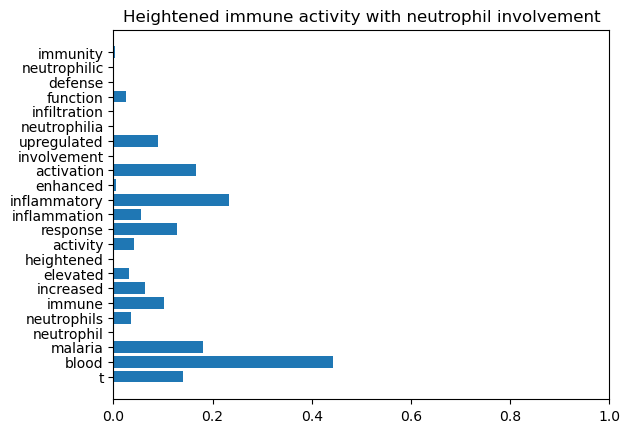

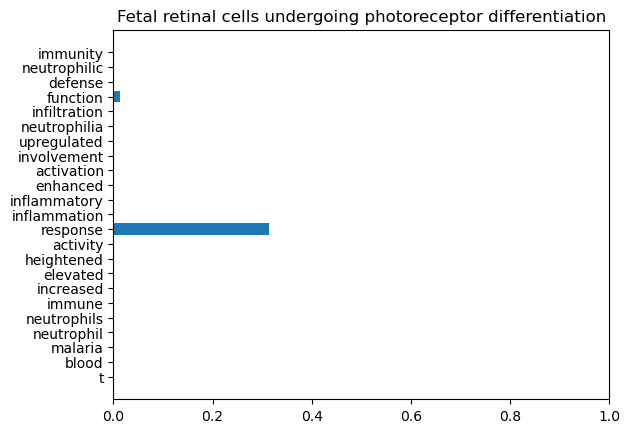

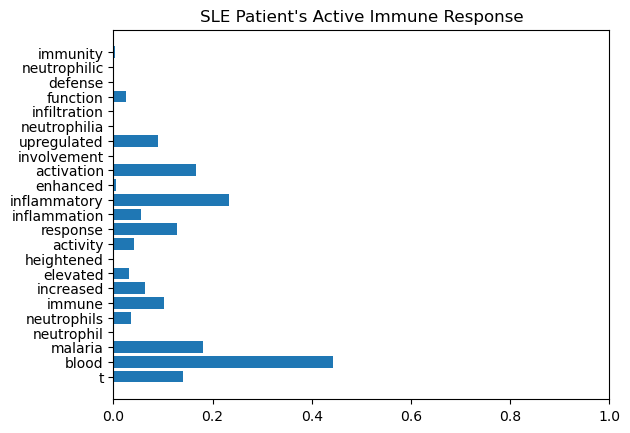

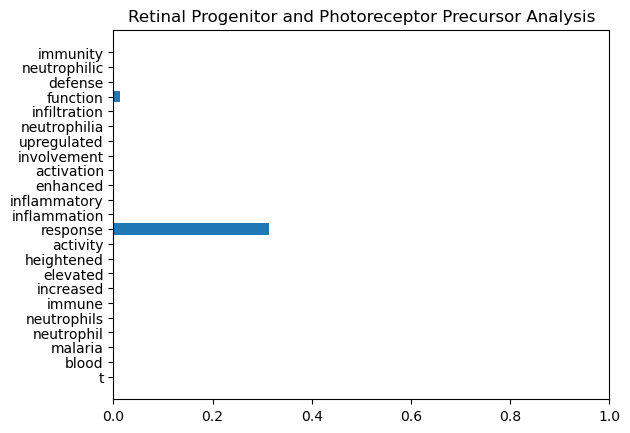

In [14]:
## Cluster-specific analysis:

MATCH_MODE="full_words" # or: full_words

cluster_scores = {}

for cluster,cluster_col in zip(["Heightened immune activity with neutrophil involvement","Fetal retinal cells undergoing photoreceptor differentiation","SLE Patient's Active Immune Response","Retinal Progenitor and Photoreceptor Precursor Analysis"],
                            ["cluster_label","cluster_label","cluster_label_old","cluster_label_old"]):

    word_scores = defaultdict(list)

    cell_ids_this_cluster = adata.obs.index[adata.obs[cluster_col]==cluster]
    metadata_df_this_cluster = metadata_df.loc[cell_ids_this_cluster]

    words=cluster.split()
    words = [word.lower() for word in words if ((word.lower() in word_categories["biomedical_terms"]))]

    words = [
        "T",
        "Blood", 
        "Malaria",
        "Neutrophil",
        "Neutrophils",
        "Immune",
        "Increased",
        "Elevated",
        "Heightened",
        "Activity",
        "Response",
        "Inflammation",
        "Inflammatory",
        "Enhanced",
        "Activation",
        "Involvement",
        "Upregulated",
        "Neutrophilia",
        "Infiltration",
        "Function",
        "Defense",
        "Neutrophilic",
        "Immunity"
    ]
    words = [word.lower() for word in words]


    if not len(words):
        print("Skipping cluster", cluster)
        continue
    n_words = len(words)
    n_cells = len(cell_ids_this_cluster)
    hits=0

    for cell_id in cell_ids_this_cluster:
        metadata = " ".join([str(x) for x in metadata_df.loc[cell_id].values])
        metadata = metadata.lower()
        if MATCH_MODE=="full_words":
            metadata = metadata.split()
        for word in words:
            if word in metadata:
                hits+=1
                word_scores[word].append(1)
            else:
                word_scores[word].append(0)

    score = hits/(n_cells*n_words)
    cluster_scores[cluster] = score

    plt.barh(word_scores.keys(), [np.mean(x) for x in word_scores.values()])
    plt.title(cluster)
    plt.xlim(0,1)
    plt.show()

In [ ]:
MATCH_MODE="full_words" # or: full_words


#remove_words=['in', 'with','and','from','to',"cells","cell", "at","for"]

old_and_new_cluster_scores = {}
old_and_new_word_scores = {}

for cluster_col, old_or_new in zip(["cluster_label_old", "cluster_label"], ["old", "new"]):

    old_and_new_word_scores[old_or_new] = defaultdict(list)
    old_and_new_cluster_scores[old_or_new] = {}

    for cluster in adata.obs[cluster_col].unique():
        cell_ids_this_cluster = adata.obs.index[adata.obs[cluster_col]==cluster]
        metadata_df_this_cluster = metadata_df.loc[cell_ids_this_cluster]

        words=cluster.split()
        words = [word.lower() for word in words if ((word.lower() in word_categories["biomedical_terms"]))]
        if not len(words):
            print("Skipping cluster", cluster)
            continue
        n_words = len(words)
        n_cells = len(cell_ids_this_cluster)
        hits=0

        for cell_id in cell_ids_this_cluster:
            metadata = " ".join([str(x) for x in metadata_df.loc[cell_id].values])
            metadata = metadata.lower()
            if MATCH_MODE=="full_words":
                metadata = metadata.split()
            for word in words:
                if word in metadata:
                    hits+=1
                    old_and_new_word_scores[old_or_new][word].append(1)
                else:
                    old_and_new_word_scores[old_or_new][word].append(0)

        score = hits/(n_cells*n_words)
        old_and_new_cluster_scores[old_or_new][cluster] = score

    old_and_new_word_scores[old_or_new]= {k:np.mean(v) for k,v in old_and_new_word_scores[old_or_new].items() if len(v)>100}

    old_and_new_cluster_scores[old_or_new] = {k: v for k, v in sorted(old_and_new_cluster_scores[old_or_new].items(), key=lambda item: item[1], reverse=True)}
    old_and_new_word_scores[old_or_new] = {k: v for k, v in sorted(old_and_new_word_scores[old_or_new].items(), key=lambda item: item[1], reverse=True)}

Skipping cluster No label


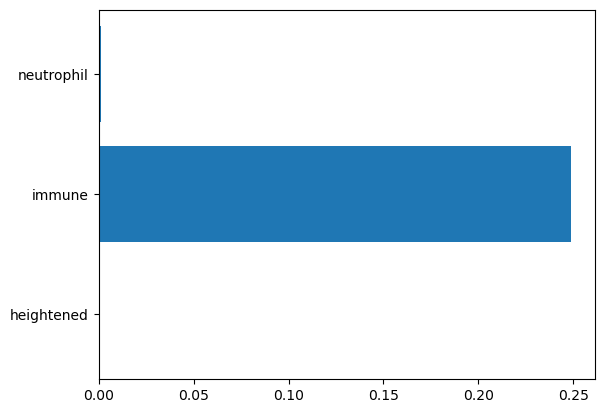

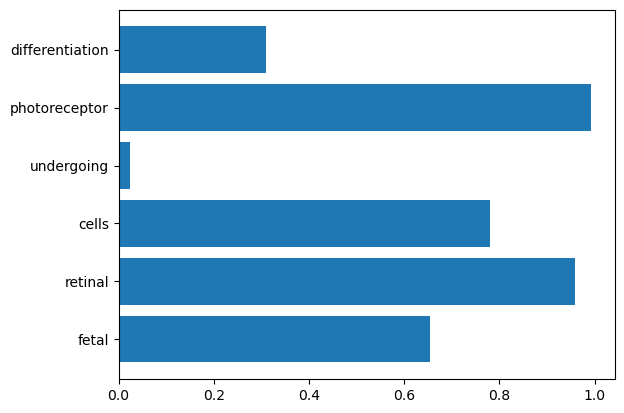

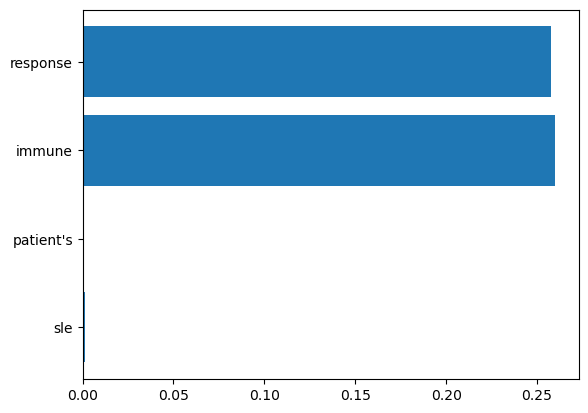

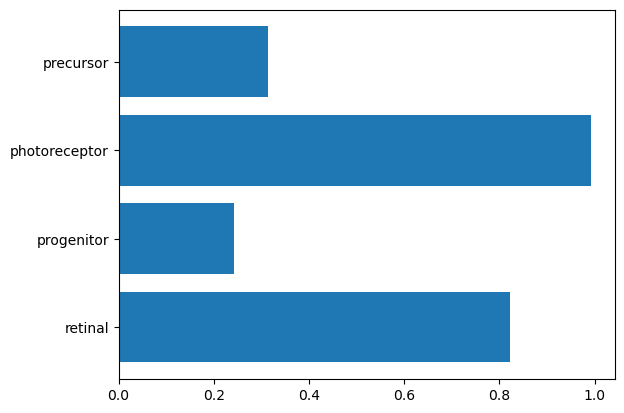

In [ ]:
select_words="Heightened immune activity neutrophil involvement".lower().split(" ")
select_words=[x for x in select_words if x in word_categories["biomedical_terms"]]
plt.barh(select_words, [old_and_new_word_scores["new"][x] for x in select_words])
plt.show()

select_words="Fetal retinal cells undergoing photoreceptor differentiation".lower().split(" ")
select_words=[x for x in select_words if x in word_categories["biomedical_terms"]]
plt.barh(select_words, [old_and_new_word_scores["new"][x] for x in select_words])
plt.show()

select_words="SLE Patient's Active Immune Response".lower().split(" ")
select_words=[x for x in select_words if x in word_categories["biomedical_terms"]]
plt.barh(select_words, [old_and_new_word_scores["old"][x] for x in select_words])
plt.show()

select_words="Retinal Progenitor and Photoreceptor Precursor Analysis".lower().split(" ")
select_words=[x for x in select_words if x in word_categories["biomedical_terms"]]
plt.barh(select_words, [old_and_new_word_scores["old"][x] for x in select_words])
plt.show()

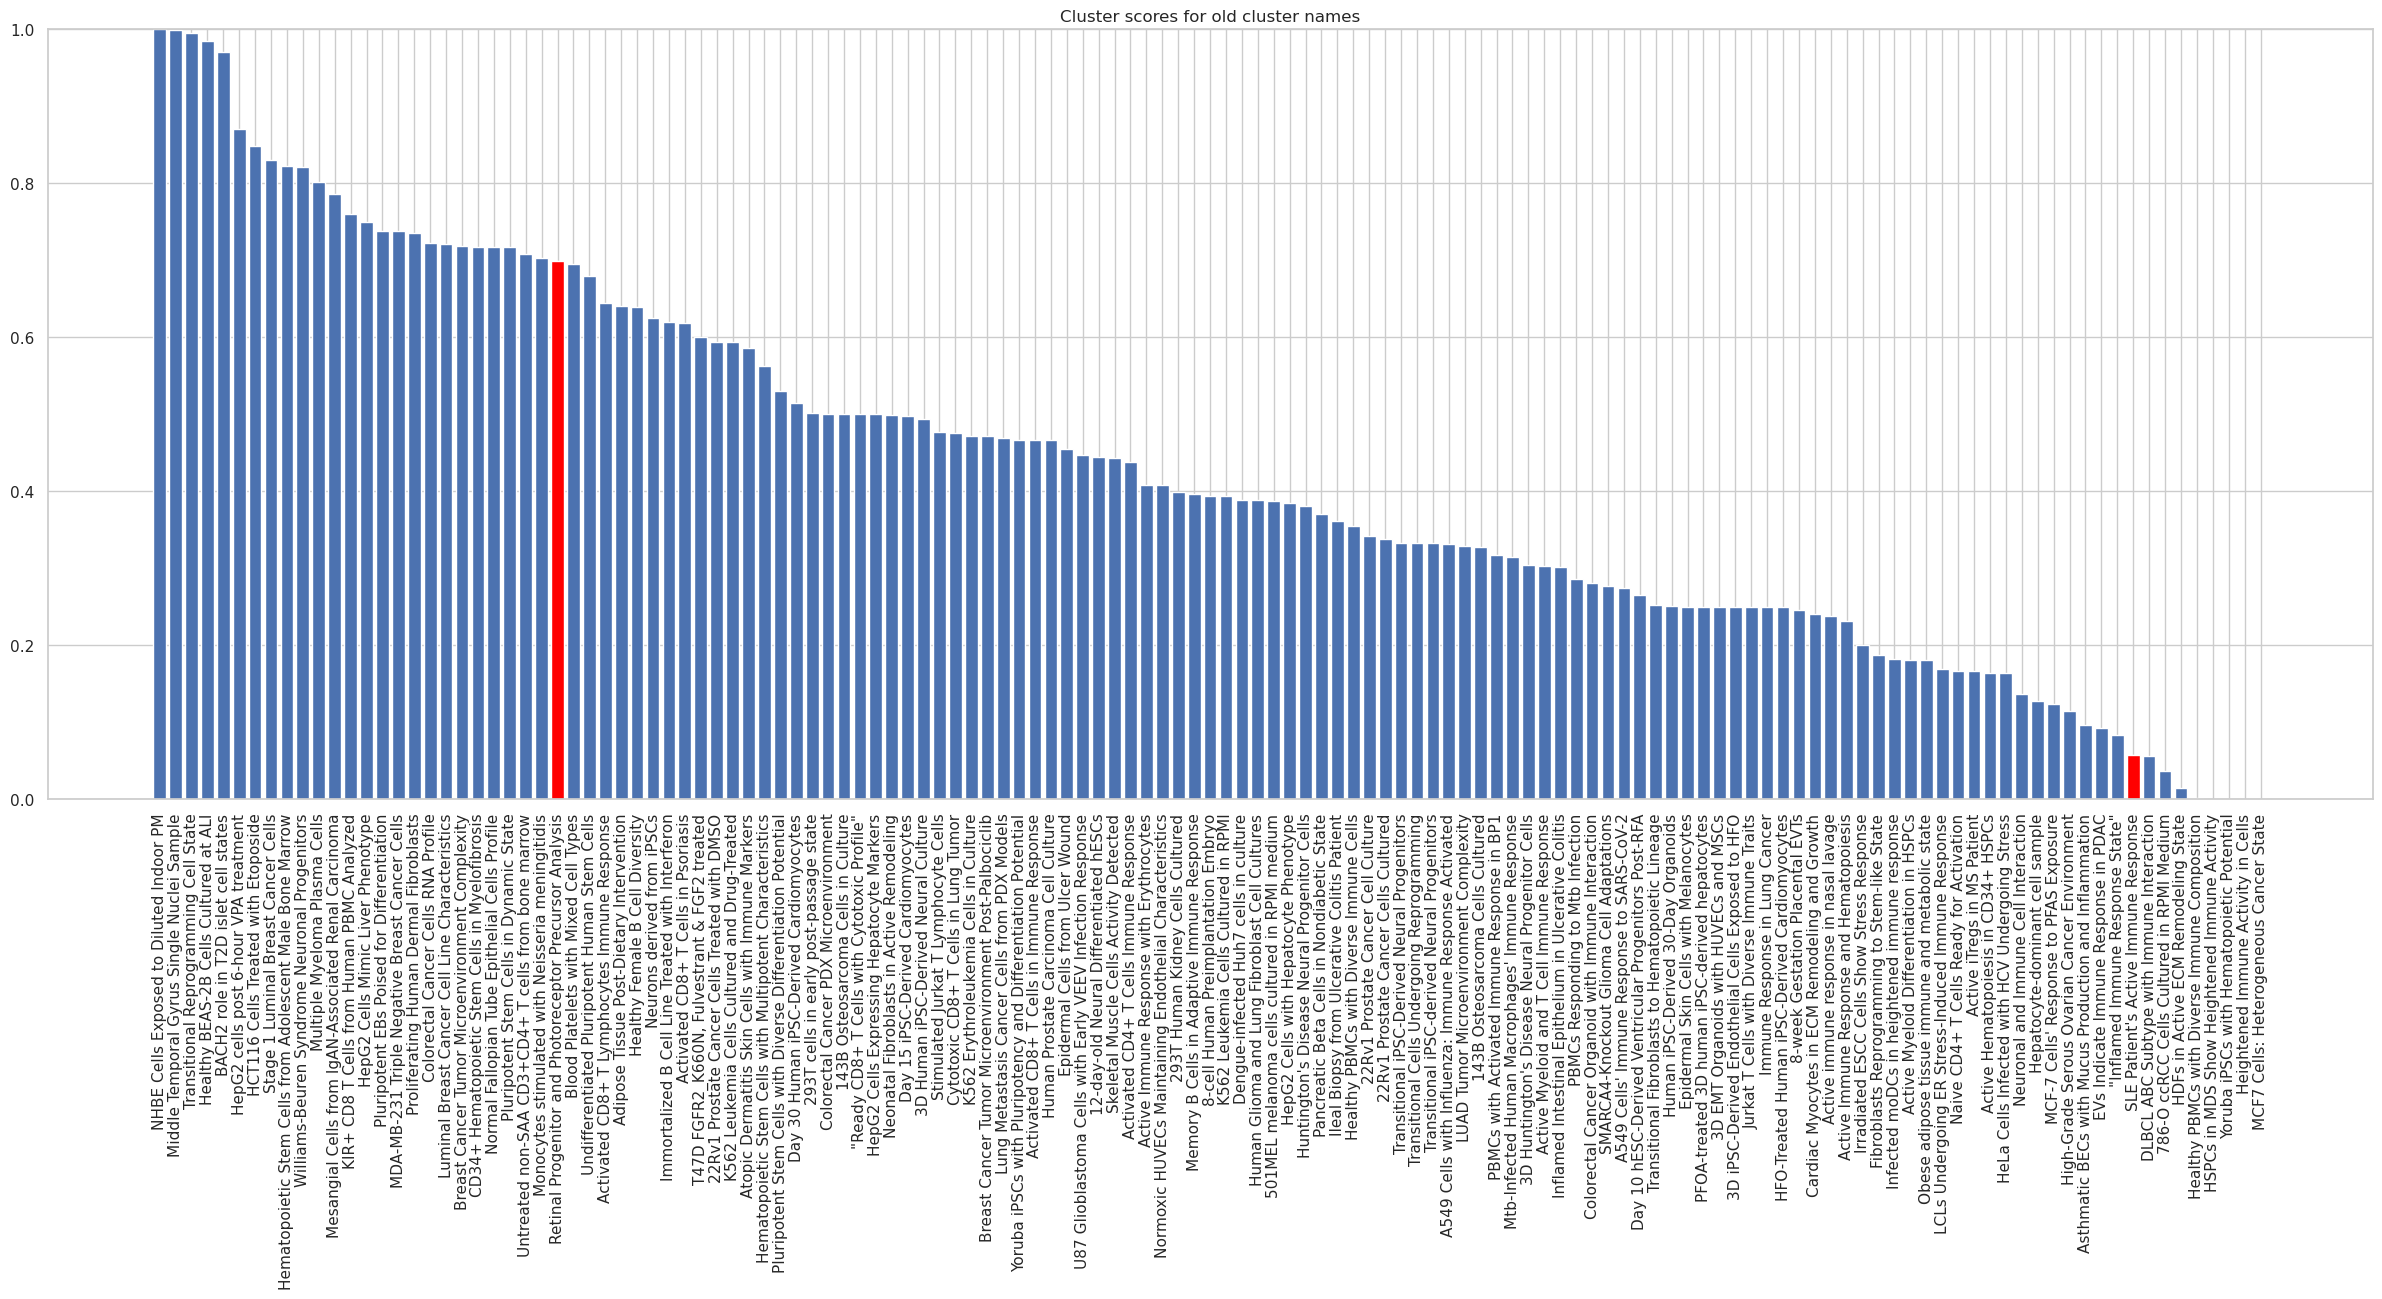

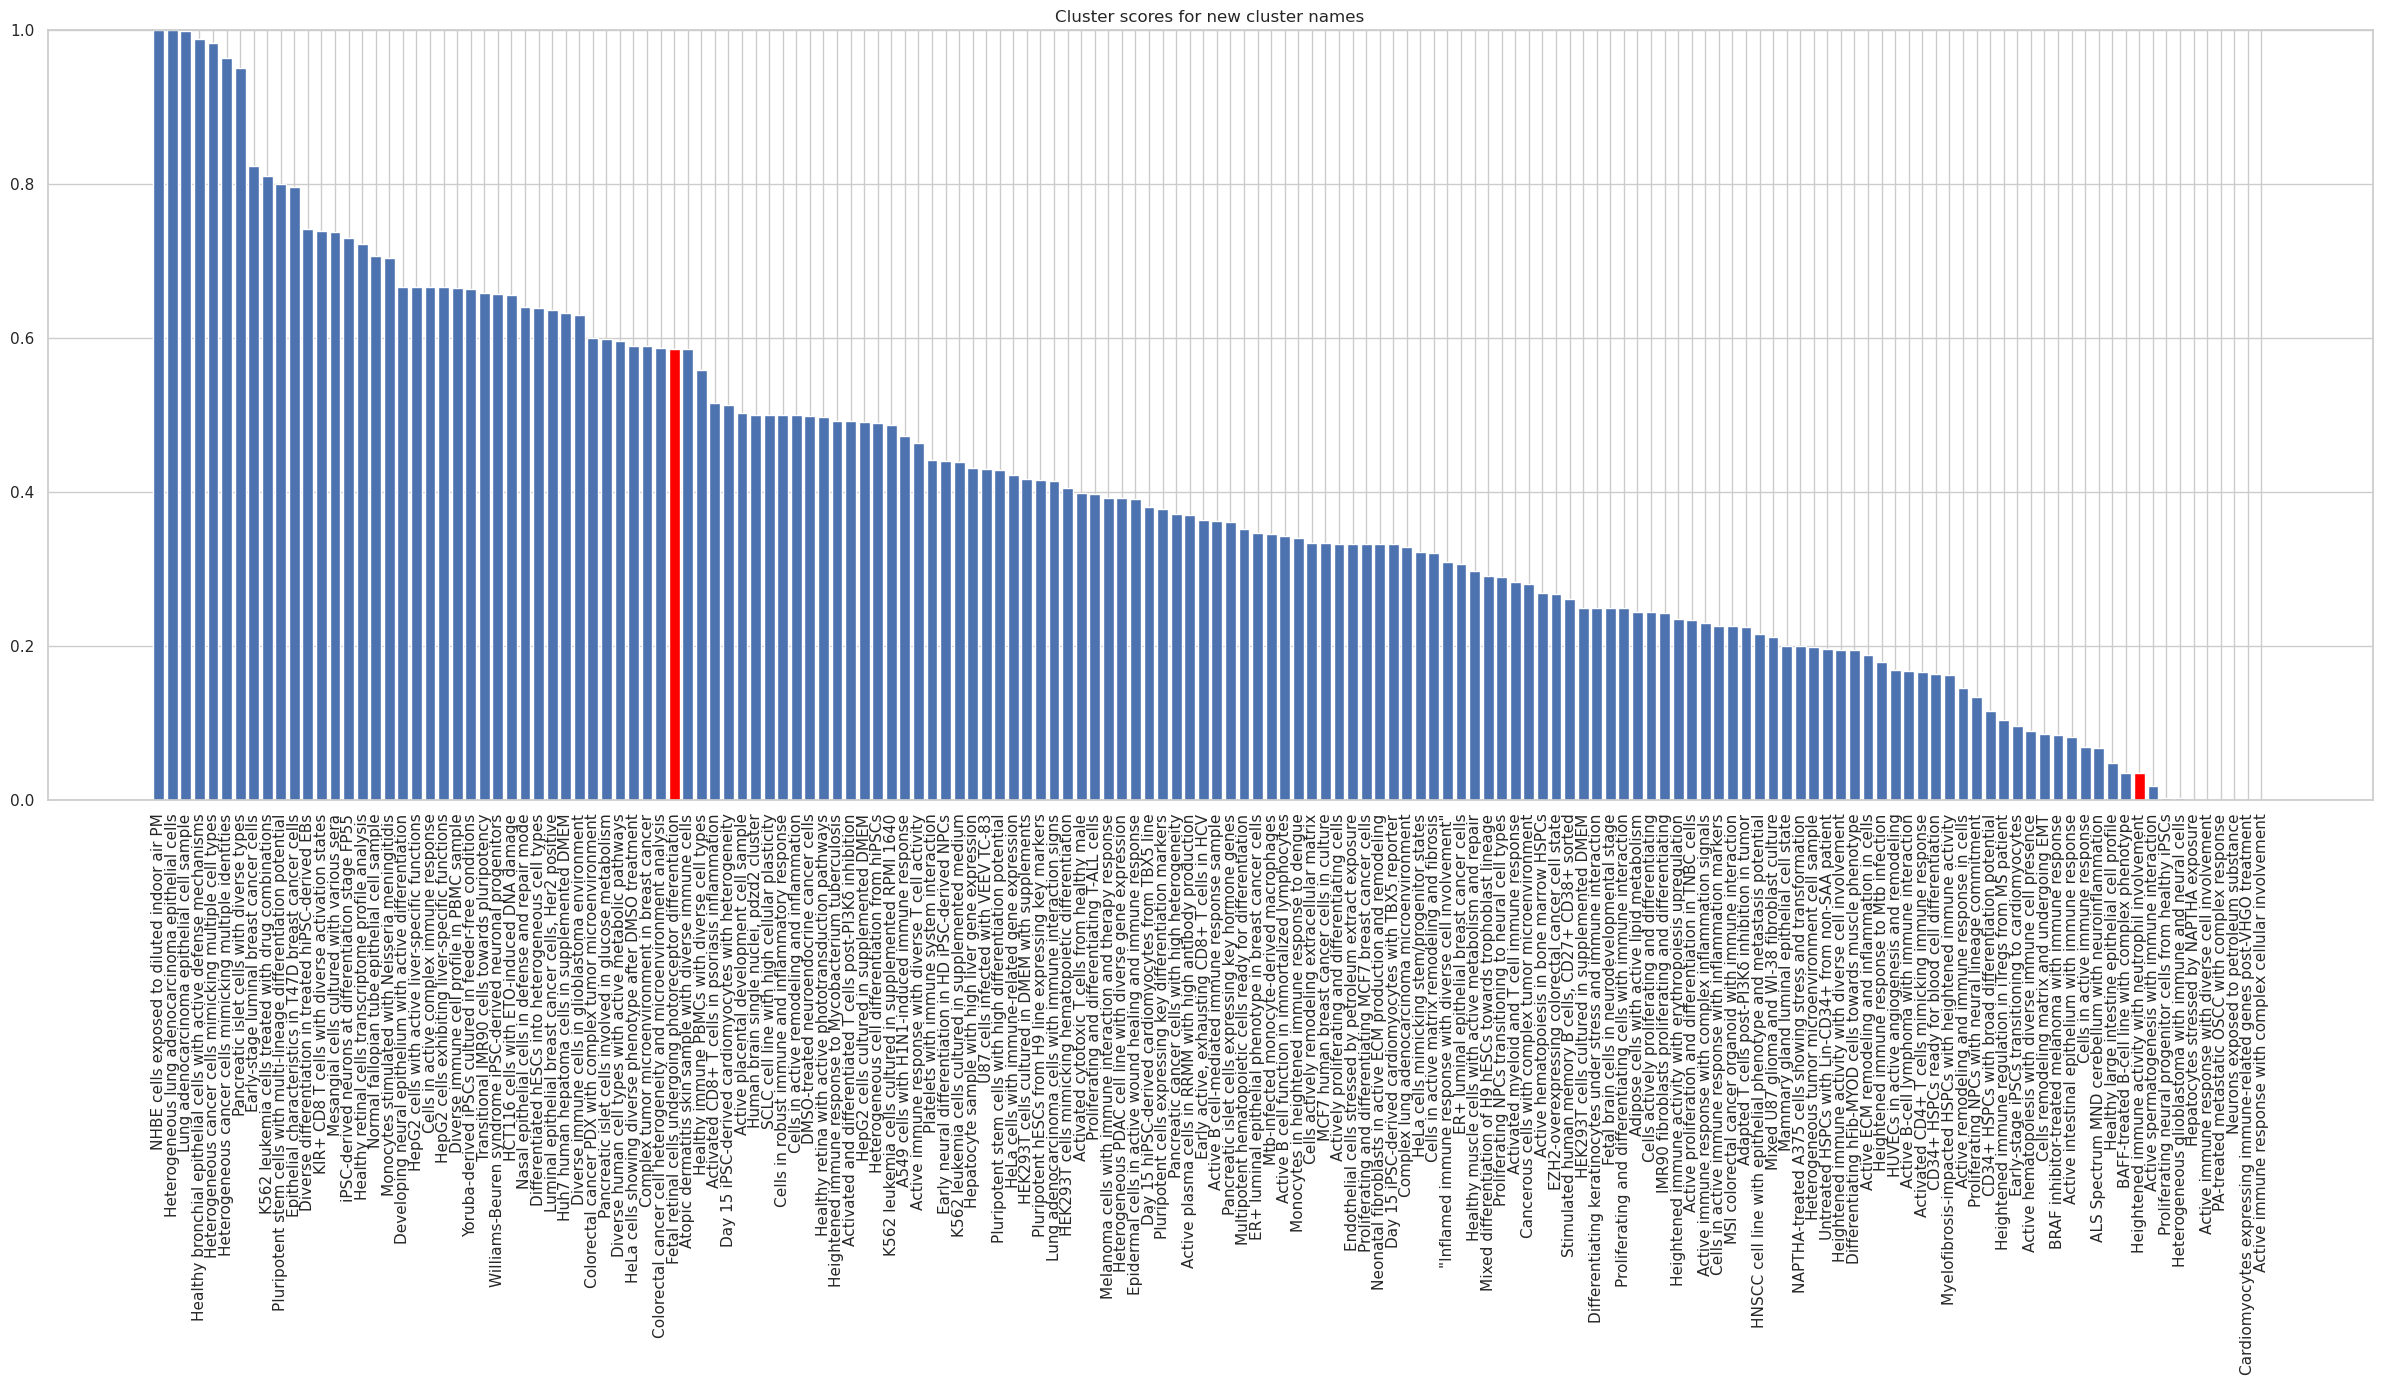

In [91]:
# plot as barplot

for old_or_new in ["old", "new"]:

    sns.set(style="whitegrid")
    plt.figure(figsize=(30,10))
    plt.xticks(rotation=90)
    plt.bar(old_and_new_cluster_scores[old_or_new].keys(), old_and_new_cluster_scores[old_or_new] .values())

    plt.ylim(0,1)

    # highlight clusters of interest
    if old_or_new == "old":
        clusters_of_interest = ["SLE Patient's Active Immune Response","Retinal Progenitor and Photoreceptor Precursor Analysis"]
    else:
        clusters_of_interest = ["Heightened immune activity with neutrophil involvement","Fetal retinal cells undergoing photoreceptor differentiation"]

    for cluster in clusters_of_interest:
        plt.bar(cluster, old_and_new_cluster_scores[old_or_new][cluster], color='red')

    plt.title(f"Cluster scores for {old_or_new} cluster names")

    plt.show()

    


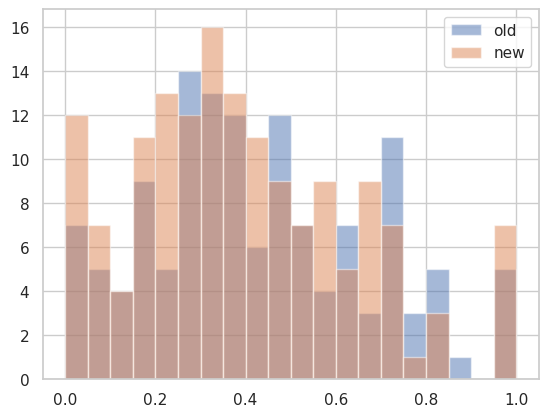

In [93]:
# compare the distribution of old and new

plt.hist(list(old_and_new_cluster_scores["old"].values()), bins=20, alpha=0.5, label='old')
plt.hist(list(old_and_new_cluster_scores["new"].values()), bins=20, alpha=0.5, label='new')
plt.legend(loc='upper right')
plt.show()



In [94]:
len([x for x in adata.obs.cluster_label_old if x =="No label"])

32847

In [69]:
for word in 'NHBE cells exposed to diluted indoor air PM'.split():
    
    print(word in metadata_df.loc[adata.obs.index[adata.obs.cluster_label=='NHBE cells exposed to diluted indoor air PM']].apply(lambda row: ' '.join(map(str, row)), axis=1).values[0])

True
True
True
True
True
True
True
True


In [100]:
adata_nat_langauge_annot.obs.loc[adata.obs.cluster_label=='NHBE cells exposed to diluted indoor air PM'].shape

(260, 36)

In [104]:
list(adata_nat_langauge_annot.obs.loc[adata.obs.cluster_label=='NHBE cells exposed to diluted indoor air PM'].natural_language_annotation.values)

['Normal human bronchial epithelial cells (NHBE), cultured as a cell line, with a damage status of 1 and likely or highly likely moisture status, treated with an unknown treatment. Sample ID 21, set 1, replicate 1, from house REM01, house pair 1, with a dose of 4 at 1:4 dilution.',
 'Normal human bronchial epithelial cells (NHBE), specifically the REM01 cell line, cultured and treated with an unknown treatment. The cells were diluted 1:4, with a damage status of 1, likely or highly likely to have moisture, and part of set 1, replicate 2.',
 'Normal human bronchial epithelial cells (NHBE), specifically the REM01 cell line, cultured and treated with an unknown treatment. The cells were diluted 1:4, with damage status 1, likely or highly likely to have moisture, and part of set 1, replicate 3.',
 'Normal human bronchial epithelial cells (NHBE), specifically the REM01 cell line, cultured and treated with an unknown treatment. The cells were diluted 1:4, with damage status 1, likely or high

In [70]:
metadata_df.loc[adata.obs.index[adata.obs.cluster_label=='NHBE cells exposed to diluted indoor air PM']].apply(lambda row: ' '.join(map(str, row)), axis=1).values[0]

'REM01, dilution 1:4, set 1, replicate 1 normal human bronchial epithelial cells source_name: normal human bronchial epithelial cells; cell_line: NHBE; set: 1; subset: 1; sample_id: 21; house_id: REM01; dose_nb: 4; dose_dil: 104; replicate: 1; house_pair_nb: 1; house_is_paired: TRUE; damage_status: 1; moisture_status_nb: 2; moisture_status_4cat: likely; moisture_status_2cat: likely or highly likely  PM sampled with the NIOSH BC251 bio aerosol cyclone sampler were combined with 2 mL of synthetic lung lining fluid (LLF) (Nordberg et al. 2020), mixed, sonicated, and diluted in LLF to three dose levels: 1:16, 1:8, and 1:4. The airway constructs were exposed to the three doses in air liquid interface (+37 °C, 5% CO2, exposure time 24 h). The exposure experiments were conducted in four sets during four months. Paired index and reference houses were always included in the same exposure set. Background - Multiple health effects are associated with moisture damage in buildings. Studies explaini

In [105]:
adata.obs.columns

Index(['geo_id', 'sample_type', 'sample_type_confidence', 'sra_uid',
       'biosample_uid', 'organism', 'database', 'accession_type',
       'molecule_ch1', 'readsaligned', 'singlecellprobability',
       'series_submission_date', 'leiden', 'cluster_label',
       'series_submission_date_cont', 'cluster_label_old'],
      dtype='object')

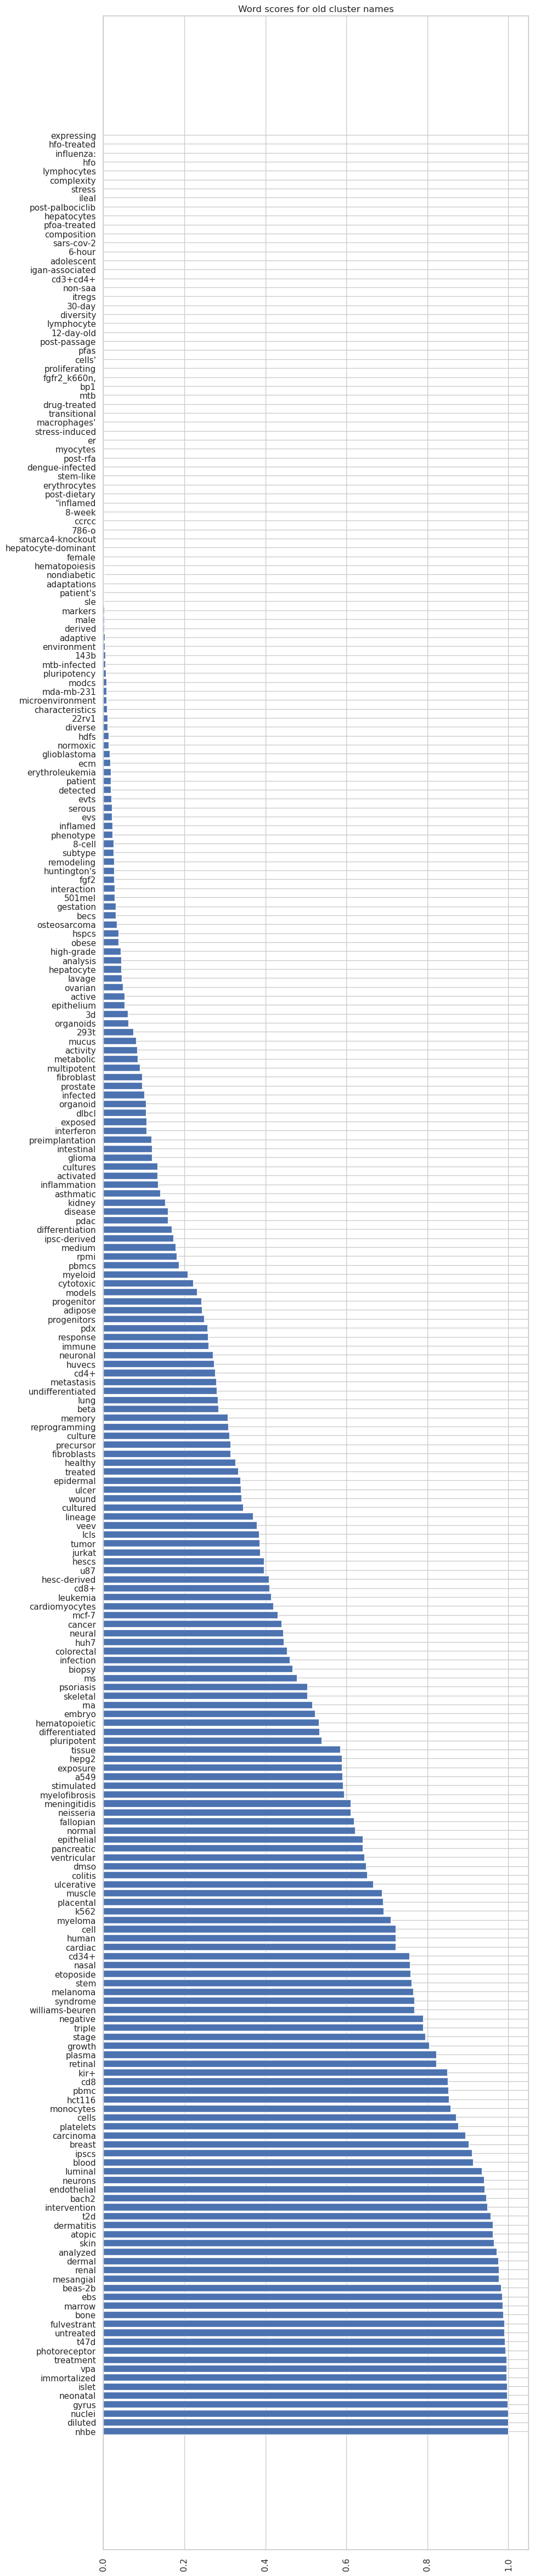

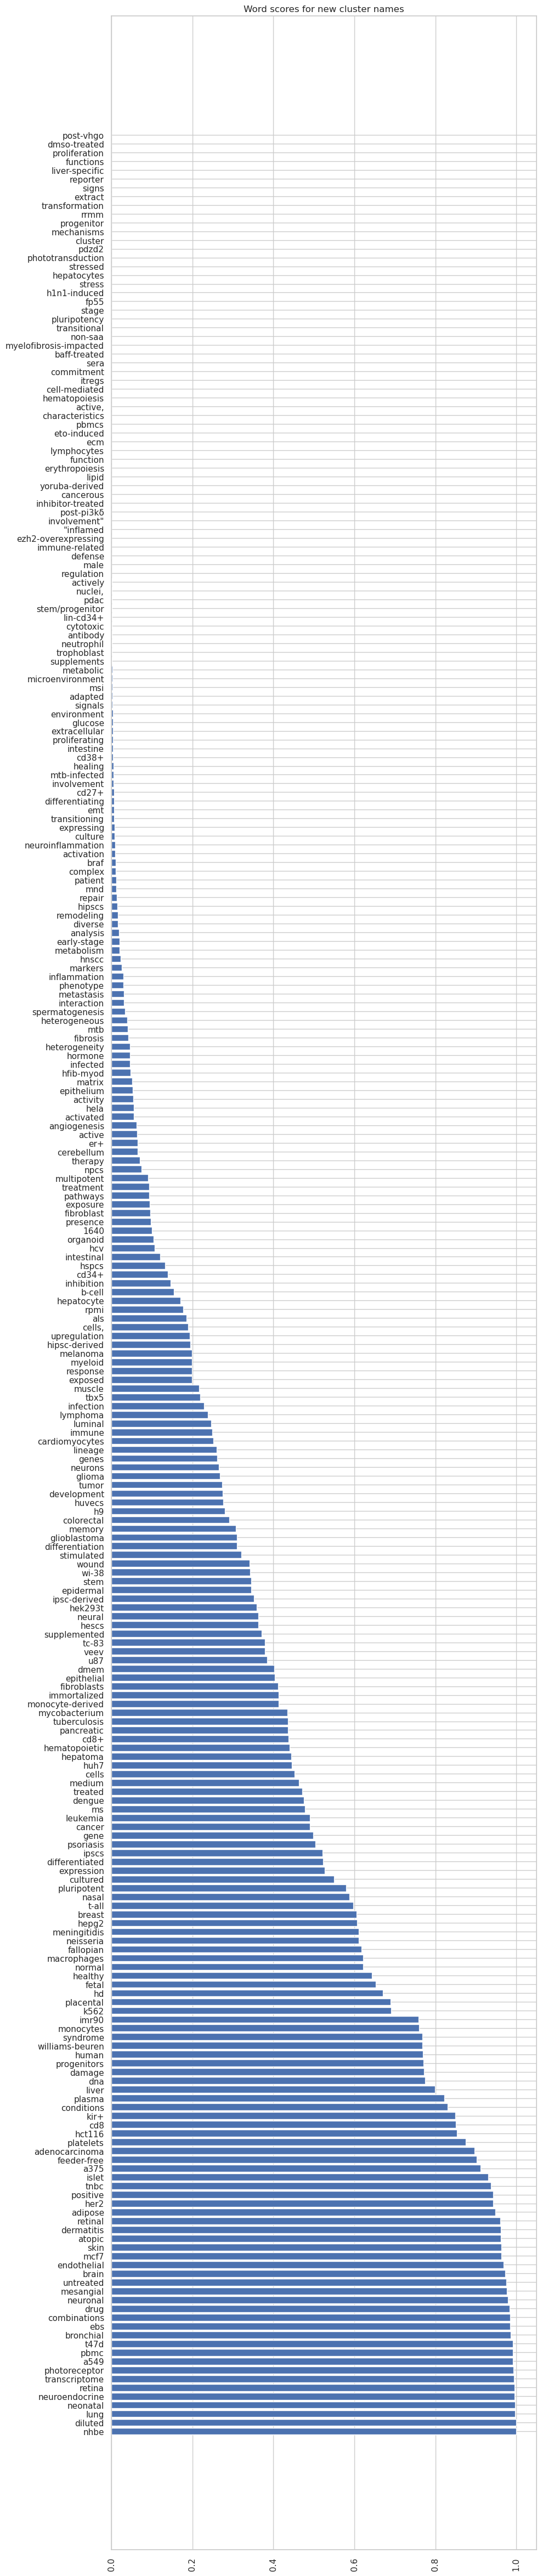

In [65]:
for old_or_new in ["old", "new"]:

    sns.set(style="whitegrid")
    # Now for words
    plt.figure(figsize=(10,60))
    plt.xticks(rotation=90)
    plt.barh(old_and_new_word_scores[old_or_new].keys(), old_and_new_word_scores[old_or_new].values())
    plt.title(f"Word scores for {old_or_new} cluster names")
    plt.show()


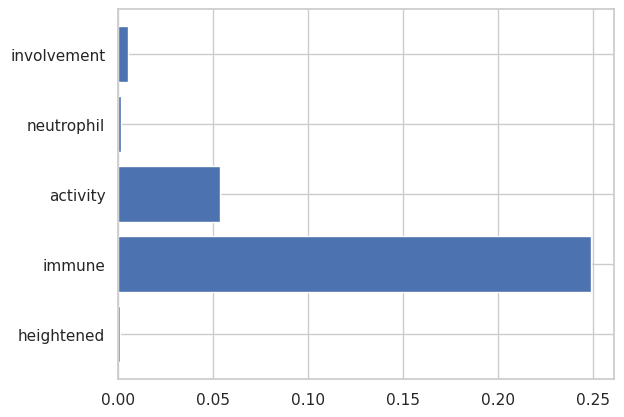

In [47]:
select_words="Heightened immune activity neutrophil involvement".lower().split(" ")
plt.barh(select_words, [old_and_new_word_scores["new"][x] for x in select_words])
plt.show()

{'"inflamed',
 '&',
 '1',
 '10',
 '12-day-old',
 '143b',
 '15',
 '1640',
 '22rv1',
 '293t',
 '30',
 '30-day',
 '3d',
 '501mel',
 '6-hour',
 '786-o',
 '8-cell',
 '8-week',
 'a375',
 'a549',
 'abc',
 'activated',
 'activation',
 'active',
 'active,',
 'actively',
 'activity',
 'adaptations',
 'adapted',
 'adaptive',
 'adenocarcinoma',
 'adipose',
 'adolescent',
 'air',
 'ali',
 'als',
 'analysis',
 'analyzed',
 'angiogenesis',
 'antibody',
 'asthmatic',
 'atopic',
 'b',
 'b-cell',
 'bach2',
 'baff-treated',
 'beas-2b',
 'becs',
 'beta',
 'biopsy',
 'blood',
 'bone',
 'bp1',
 'braf',
 'brain',
 'breast',
 'broad',
 'bronchial',
 'by',
 'cancer',
 'cancerous',
 'carcinoma',
 'cardiac',
 'cardiomyocytes',
 'ccrcc',
 'cd27+',
 'cd3+cd4+',
 'cd34+',
 'cd38+',
 'cd4+',
 'cd8',
 'cd8+',
 'cell',
 'cell-mediated',
 'cells',
 "cells'",
 'cells,',
 'cerebellum',
 'characteristics',
 'cluster',
 'colitis',
 'colorectal',
 'combinations',
 'commitment',
 'complex',
 'complexity',
 'composition',
 'c

In [44]:
clusters_of_interest=[#"SLE Patient's Active Immune Response"]
                      "Retinal Progenitor and Photoreceptor Precursor Analysis"]#+adata.obs.cluster_label.unique()[0:10].tolist()



In [21]:
metadata_df.loc[adata.obs.index[adata.obs.cluster_label=='BACH2 role in T2D islet cell states']]

,geo_title,geo_source_name,raw_biosample_metadata,treatment,treatment_protocol,series_summary,series_design,growth_protocol
experiment,,,,,,,,
SRX376824,cell.beta,None,source_name: NULL; condition: control; tissue:...,,FACS sorting on dispersed human islets was per...,Type 2 diabetes mellitus (T2DM) is a multi-fac...,There are three experiments in this submission...,Human islets and relevant donor information in...
SRX1304155,islet_single_cell_13,pancreatic islet,source_name: pancreatic islet; assigned cell t...,,Islets were cultured in CMRL medium (Life tech...,We report the single-cell RNA-seq based identi...,Transcriptional dissection of human pancreatic...,None
SRX1304159,islet_single_cell_17,pancreatic islet,source_name: pancreatic islet; assigned cell t...,,Islets were cultured in CMRL medium (Life tech...,We report the single-cell RNA-seq based identi...,Transcriptional dissection of human pancreatic...,None
SRX1304165,islet_single_cell_23,pancreatic islet,source_name: pancreatic islet; assigned cell t...,,Islets were cultured in CMRL medium (Life tech...,We report the single-cell RNA-seq based identi...,Transcriptional dissection of human pancreatic...,None
SRX1304188,islet_single_cell_46,pancreatic islet,source_name: pancreatic islet; assigned cell t...,,Islets were cultured in CMRL medium (Life tech...,We report the single-cell RNA-seq based identi...,Transcriptional dissection of human pancreatic...,None
...,...,...,...,...,...,...,...,...
SRX9853782,pancreatic cells for patch-seq [P2A5],pancreatic islets,source_name: pancreatic islets; diagnosis: Non...,,None,Combined single-cell RNAseq and electrophysiol...,The dataset contains 640 pancreas patch-seq ce...,None
SRX9853852,pancreatic cells for patch-seq [P2G3],pancreatic islets,source_name: pancreatic islets; diagnosis: Non...,,None,Combined single-cell RNAseq and electrophysiol...,The dataset contains 640 pancreas patch-seq ce...,None
SRX12155392,Endo_PLIN2OE_2,EndoCbH2-Cre cells,source_name: EndoCbH2-Cre cells; cell_type: En...,,"Lentivirus mediated scramble control (Sham), s...",Free fatty acids (FFAs) are often stored in li...,Bulk RNAseq was performed in 3 groups of EndoC...,regular EndoC cell media


In [22]:
metadata_df.loc[adata.obs.index[adata.obs.cluster_label=='HeLa Cells Infected with HCV Undergoing Stress']]

,geo_title,geo_source_name,raw_biosample_metadata,treatment,treatment_protocol,series_summary,series_design,growth_protocol
experiment,,,,,,,,
SRX15221241,HK2_2_DMSO_1,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221242,HK2_2_DMSO_2,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221243,HK2_2_DMSO_3,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221244,HK2_2_DMSO_4,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221245,HK2_2_DMSO_5,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221246,HK2_2_DMSO_6,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221247,HK2_2_DMSO_7,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221248,HK2_2_DMSO_8,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...
SRX15221249,HK2_2_DMSO_9,HK-2,source_name: HK-2; cell_line: HK-2; cell_type:...,treatment: 0.50%_DMSO,HK-2 cells were treated with TCM crude extract...,The Wenshenyang recipe (WSYR) has the effect o...,HK-2 cells were cultured in a 384-well plate f...,HK-2 cells were maintained in DMEM containing ...


In [ ]:
remove_words=['Cells','in', 'with','and', "Cell",'from','to',"cells","cell"]


for word in word_counts.keys():


for cluster in adata.obs.cluster_label.unique():
    cell_ids_this_cluster = adata.obs.index[adata.obs.cluster_label==cluster]
    metadata_df_this_cluster = metadata_df.loc[cell_ids_this_cluster]

    words=cluster.split()
    words = [word for word in words if word not in remove_words]
    n_words = len(words)
    n_cells = len(cell_ids_this_cluster)
    hits=0

    for cell_id in cell_ids_this_cluster:
        metadata = " ".join([str(x) for x in metadata_df.loc[cell_id].values])
        for word in words:
            if word in metadata:
                hits+=1

    score = hits/(n_cells*n_words)
    score_per_cluster[cluster] = score

In [30]:

for i,cluster in enumerate(clusters_of_interest):
    print("\nCluster name: ",cluster)
    cell_ids_this_cluster = adata.obs.index[adata.obs.cluster_label==cluster]
    metadata_df_this_cluster = metadata_df.loc[cell_ids_this_cluster]

    if "SLE" in cluster:
        keywords=["SLE","lupus","Lupus","auto","Auto"]
    elif "Retinal" in cluster:
        keywords=["retina","Retina","photoreceptor","Photoreceptor","progenitor","Progenitor"]
    else:
        raise ValueError("No keywords for cluster: "+cluster)

    for keyword in keywords:
        # how many rows in the metadata contain the keyword in any column?
        metadata_df_this_cluster[f"contains_keyword_{keyword}"] = metadata_df_this_cluster.apply(lambda row: any([keyword in str(cell) for cell in row]), axis=1)
        metadata_df_this_cluster[f"cells"] = 1

    print(metadata_df_this_cluster[[f"contains_keyword_{keyword}" for keyword in keywords]+["cells"]].sum())


Cluster name:  Retinal Progenitor and Photoreceptor Precursor Analysis
contains_keyword_retina           2277
contains_keyword_Retina           2264
contains_keyword_photoreceptor    2273
contains_keyword_Photoreceptor      70
contains_keyword_progenitor       1522
contains_keyword_Progenitor          0
cells                             2285
dtype: int64


In [27]:
metadata_df_this_cluster

,geo_title,geo_source_name,raw_biosample_metadata,treatment,treatment_protocol,series_summary,series_design,growth_protocol,contains_keyword_SLE,cells,contains_keyword_lupus,contains_keyword_Lupus,contains_keyword_auto,contains_keyword_Auto
experiment,,,,,,,,,,,,,,
SRX218961,DCK1,HEK293,source_name: HEK293; cell_line: HEK293; antibo...,,None,"Background: In recent years, a variety of smal...",PAR-CLIP profiling for snoRNP core proteins NO...,HEK293 and HeLa cells were routinely generated...,False,1,False,False,False,False
SRX220096,ORF1p/RNP replicate 2,HEK293T,source_name: HEK293T; cell_line: HEK293T,,The PAR-CLIP protocol was performed as describ...,We explored the RNA binding properties of LINE...,PAR-CLIP analysis of L1 RNPs and free ORF1p RN...,HEK293T cells were maintained in a tissue cult...,False,1,False,False,False,False
SRX286279,"Wild Type Staufen associated, RNase treated mRNA",HEK293T cells transfected with pChStaufen-TAP,source_name: HEK293T cells transfected with pC...,transfection with: pChStaufen-TAP,HEK293T cells were transfected with DNA plasmi...,Cellular mRNAs are permanently associated to p...,Staufen (wild type or mutant) associated RNAs ...,"The HEK293T (DuBridge et al, 1987) cell line w...",False,1,False,False,False,False
SRX326610,PN41_s_8,serum,source_name: serum; er status: pos; pr status:...,,Pre-treatment sera from BC patients were used.,MicroRNAs (miRNAs) have been recently detected...,The pre-treatment sera of 42 stage II–III loca...,None,False,1,False,False,False,False
SRX344563,M3-ip,Human 293T,source_name: Human 293T; cell_line: 293T; trea...,treatment: METTL3 overexpressed,None,label the cells overexpressed Myc tagged METTL...,discovery of the binding motif of METTL3，WTAP ...,None,False,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRX19842579,"20141a008, noSAD, noELA",peripheral blood,source_name: peripheral blood; sad status: noS...,,None,Social anxiety disorder (SAD) is a psychiatric...,Comparative gene expression profiling analysis...,None,False,1,False,False,False,False
SRX19842577,"20141a009, SAD, noELA",peripheral blood,source_name: peripheral blood; sad status: SAD...,,None,Social anxiety disorder (SAD) is a psychiatric...,Comparative gene expression profiling analysis...,None,False,1,False,False,False,False
SRX19842660,"20141a027, noSAD, ELA",peripheral blood,source_name: peripheral blood; sad status: noS...,,None,Social anxiety disorder (SAD) is a psychiatric...,Comparative gene expression profiling analysis...,None,False,1,False,False,False,False


In [31]:
adata.obs[adata.obs.cluster_label==cluster].leiden

experiment
SRX1456768     74
SRX2480491     74
SRX2784134     74
SRX2784135     74
SRX2784136     74
               ..
SRX19157638    74
SRX19157639    74
SRX19157640    74
SRX19157641    74
SRX19157642    74
Name: leiden, Length: 2285, dtype: category
Categories (157, object): ['0', '1', '2', '3', ..., '153', '154', '155', '156']

In [5]:

for i,cluster in enumerate(clusters_of_interest):
    print(f"\n\n############################\n"
          f"Top 10 annotations/terms of cluster {cluster} (Total cells: {adata.obs[adata.obs.cluster_label==cluster].shape[0]}:\n")
    for col in ["natural_language_annotation","mapped_ontology_terms"]:
        metadata_counts=adata.obs[adata.obs.cluster_label==cluster][col].value_counts()
        # remove zero counts
        metadata_counts=metadata_counts[metadata_counts>0]


        if col == "mapped_ontology_terms":
            # Ensure index is string type
            metadata_counts.index = metadata_counts.index.astype(str)
            
            # Split terms in index and count occurrences weighted by their original counts
            term_counts = Counter()
            for metadata_terms, count in metadata_counts.items():
                terms = metadata_terms.split(", ")  # Adjust delimiter if necessary
                term_counts.update({term.strip(): count for term in terms})  # Weight terms by their counts
            
            # Convert to Series and sort
            metadata_counts = pd.Series(term_counts).sort_values(ascending=False)
        print("\n")
        print(metadata_counts[:10])

        # Save as yaml: The cluster label and all metadata terms
        import yaml
        with open(f"metadata_terms_{i}_{col}.yaml", "w") as f:
            yaml.dump({cluster: metadata_counts.index.tolist()}, f)

        # also save the counts:
        metadata_counts.to_csv(f"metadata_counts_{i}_{col}.csv")


        # if "SLE" in cluster:
        #     for keyword in ["SLE","lupus","Lupus","auto","Auto"]:
        #         print([x for x in metadata_counts.index if keyword in x])
        # if "Retinal Progenitor and Photoreceptor Precursor Analysis" in cluster:
        #     for keyword in ["retina","Retina","photoreceptor","Photoreceptor","progenitor","Progenitor"]:
        #         print([x for x in metadata_counts.index if keyword in x])    




############################
Top 10 annotations/terms of cluster SLE Patient's Active Immune Response (Total cells: 10345:



Primary CD4 T cells from a human PBMC sample, previously vaccinated with the RV144 vaccine regimen.                         211
Primary cells from sorted bone marrow macrophages (CD14+CD163+) with no treatment.                                          142
ETP-ALL (Early T-cell precursor acute lymphoblastic leukemia) cells isolated from NSG spleen.                                89
Primary cells from a colon tissue of a human patient with colorectal adenocarcinoma.                                         65
Patient-derived glioma tissue sample named G18 with IDH1mt_TP5                                                               53
BT869 cell line, specifically H3.3K27M-glioma with SMARCA4 knockout, after 4 days of nucleofection treatment.                52
T-cell acute lymphoblastic leukemia (T-ALL) cells isolated from NSG spleen.                             

In [43]:
metadata_counts.index[1]

'stem cell'

In [44]:
metadata_counts

retina                           1371
stem cell                         907
embryonic stem cell               873
cultured cell                     835
cell line                         833
H9                                803
WA09                              803
late embryonic stage              718
late embryo                       718
treatment                         399
retinal cone cell                 258
retinal rod cell                  151
adult organism                    126
adult                             126
pluripotent stem cell              65
induced pluripotent stem cell      65
somatic stem cell                  65
GM23338                            28
optic cup                          11
neuron                              3
muscle belly                        2
CV-hIPS-B                           2
pallium                             1
ventral part of telencephalon       1
female organism                     1
islet of Langerhans                 1
R1-hiPSC7   

In [ ]:
from llama_cpp import (
    Llama,
    LlamaGrammar,
)
import json
import yaml
import pandas as pd
from pathlib import Path
import logging

temperature = 0.2 

PROJECT_DIR = Path(subprocess.check_output("git rev-parse --show-toplevel", shell=True).decode("utf-8").strip())


# load the model
llm = Llama(
    model_path=PROJECT_DIR / config["model_name_path_map"]["mixtral"],
    n_ctx=32000,  # The max sequence length to use - note that longer sequence lengths require much more resources
    n_threads=5,  # The number of CPU threads to use
    n_threads_batch=25,
    n_gpu_layers=86,  # High enough number to load the full model
)




# Create a generalized prompt format for scoring cell descriptions
def build_scoring_prompt(cell_descriptions):
    prompt = (
        "I have a cluster labeled '<Cluster Label>'. Please score each cell based on how well its individual textual "
        "metadata description matches the focus of the cluster label. Score from 0 to 10 based on relevance. "
        "The score should reflect how closely the sample's description aligns with the general theme of the cluster, "
        "considering factors like cell type, developmental stage, tissue origin, and experimental context.\n\n"
        "Cell Descriptions:\n"
    )
    prompt += "\n".join([f"{i+1}. {desc}" for i, desc in enumerate(cell_descriptions)])
    prompt += "\n\nScores (in order of input):\n"
    return prompt


results = []
requests = []

# Assuming `cell_descriptions` is being passed as part of `yaml_split`
for key, sample in yaml_split.items():
    # Prepare the cell descriptions to be used in the prompt
    cell_descriptions = sample["cell_descriptions"]  # adjust this to how the data is structured
    serialized_sample = build_scoring_prompt(cell_descriptions)
    
    # trim to reasonable length (20000 * 4 characters per token), just in case (to avoid OOMs and other errors)
    if len(serialized_sample) > 80000:
        logging.warning(f"Sample {key} too long, trimming to 80000 characters")
        serialized_sample = serialized_sample[:80000]
    
    prompt = prompt_template.format(query=serialized_sample)
    requests.append(prompt)

    for i in range(10):
        output = llm(
            f"<s>[INST] {prompt} [/INST] ",
            max_tokens=1024,  # for training, we only use a max of 128. observe whether this matches..
            stop=["</s>"],  # stop token for Mixtral
            echo=False,  # don't echo the prompt as part of the response
            seed=hash(f"{key}{snakemake.wildcards.replicate}{i}") % 2**30,
            grammar=LlamaGrammar.from_json_schema(
                Path(snakemake.input.json_schema).read_text()
            ),
            temperature=temperature + i * 0.2,
            top_p=0.9 + (i * 0.01),
            top_k=50 + (i * 20),
        )

        result_serial = output["choices"][0]["text"].strip()
        logging.debug(result_serial)
        try:
            # Assuming the result comes back as a dictionary or list of scores
            result = json.loads(result_serial)  # Parsing the response as a JSON object
        except (json.JSONDecodeError, KeyError) as e:
            logging.warning(f"Failed to decode JSON: {e}. Retrying {i}")
            continue

        # Only accept results that are not too short
        if len(result) > 20:
            break
        else:
            logging.warning(
                f"Too short response for sample {key}: {result}. Retrying {i}"
            )
    else:
        result = "No information available for this sample"
        logging.warning(
            f"Prompt template continuously failed: \n{serialized_sample}\n{sample}\n{result_serial}"
        )

    results.append(
        {
            "sample_id": key,
            "replicate": int(snakemake.wildcards.replicate),  # type: ignore [reportUndefinedVariable]
            "annotation": result,
        }
    )

# Convert the results into a pandas DataFrame and save as CSV
pd.DataFrame(results, columns=["sample_id", "replicate", "annotation"]).to_csv(
    snakemake.output.processed_annotation, index=False
)

# Save the requests made to a YAML file
with open(snakemake.output.requests, "w") as f:
    yaml.dump(requests, f)
